https://github.com/amadda0616-hash/Flipchip_surrogate/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%85%8B%201.zip
의 .zip파일에 압축되어있는 .csv 파일과
https://github.com/amadda0616-hash/Flipchip_surrogate/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%85%8B%202.zip
의 .zip파일에 압축되어있는 .csv 파일을 하나로 합치고

https://github.com/amadda0616-hash/Flipchip_surrogate/blob/main/README.md
에 있는 내용중에

Step 1: 대리 모델(Surrogate)을 통한 데이터 증강 (Data Augmentation)
목표: 800여 개의 생존 데이터 한계를 극복하기 위해 가상 데이터를 생성.
방법: 생존한 데이터의 '절댓값 Max Peak' 지표들을 추출하여 머신러닝(XGBoost 또는 GPR) 학습. 이후 난수 생성기(Monte Carlo)로 10만 개의 가상 P1~P6 조합을 만들고 Y값들을 예측함.

처럼 python에서 코드를 구성하고 EDA를 하고나서 가상 데이터를 만들고싶어

증강 데이터는
7. 진행 과정 (The Process)의 Step 1 내용대로 LHS기법으로 난수를 생성하고 원본과 일관성이 있는지 시각적으로 검증하는 그래프를 만들어줘.

추가로
6-Dimension Geometric Parameter 정의서
에서 Time별로 P1부터 P6까지 있는 탐색 범위를 넘어가지 않는 샘플 데이터를 구하는 코드를 추가해서 구성하고 시각화를 끝낸 후에 요약된 정보를 보여줘.

In [1]:
import pandas as pd
import numpy as np
import os
import xgboost as xgb
from scipy.stats import qmc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
# 1. 데이터 통합 및 지표 추출 (Dataset 1 & 2)
def load_and_merge_data(master_path, folder_list):
    master_df = pd.read_csv(master_path)
    p_columns = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
    processed_list = []

    print("데이터 로드 및 '절댓값 Max Peak' 추출 중...")
    for i, row in master_df.iterrows():
        file_name = f'ML_DATA_Extract_Row_{i}.csv'
        found = False
        for folder in folder_list:
            file_path = os.path.join(folder, file_name)
            if os.path.exists(file_path):
                df_detail = pd.read_csv(file_path)
                df_detail.columns = df_detail.columns.str.strip()
                
                # 'Die_SY_Max'의 절댓값 중 최대값 추출
                max_peak = df_detail['Die_SY_Max'].abs().max()
                
                row_dict = row.to_dict()
                row_dict['Max_Peak'] = max_peak
                processed_list.append(row_dict)
                found = True
                break
    
    return pd.DataFrame(processed_list)

In [3]:
# 경로 설정
folders = ['D:/AI_Study/GitHub/Battery/데이터셋/', 'D:/AI_Study/GitHub/Battery/데이터셋 2/']
df_final = load_and_merge_data('D:\AI_Study\GitHub\Battery\Master_DOE_1200.csv', folders)
p_cols = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']

데이터 로드 및 '절댓값 Max Peak' 추출 중...


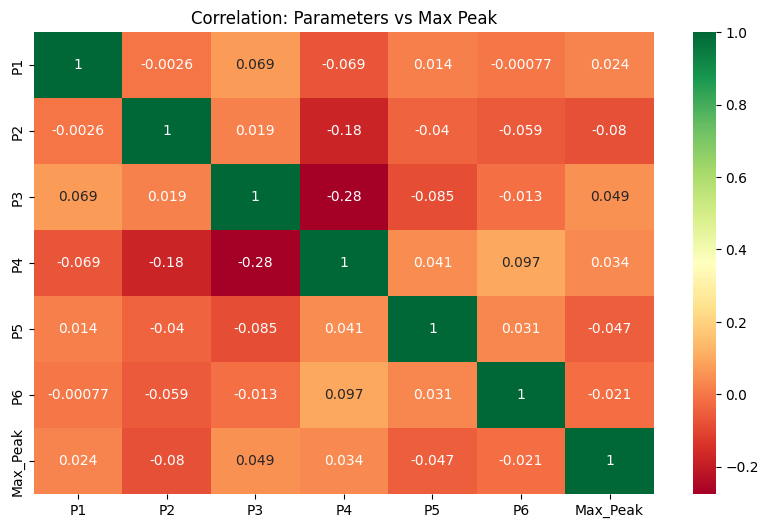

In [4]:
# 2. 기초 EDA
plt.figure(figsize=(10, 6))
sns.heatmap(df_final[p_cols + ['Max_Peak']].corr(), annot=True, cmap='RdYlGn')
plt.title("Correlation: Parameters vs Max Peak")
plt.show()

In [5]:
# 3. 대리 모델(Surrogate) 학습
X = df_final[p_cols]
y = df_final['Max_Peak']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [6]:
# 4. LHS 기법을 이용한 가상 데이터 10만 개 생성 (범위 준수)
n_virtual = 100000
p_min = df_final[p_cols].min().values
p_max = df_final[p_cols].max().values

sampler = qmc.LatinHypercube(d=len(p_cols), seed=42)
sample_raw = sampler.random(n=n_virtual)
# AttributeError 방지를 위한 직접 스케일링
virtual_samples = p_min + sample_raw * (p_max - p_min)

df_virtual = pd.DataFrame(virtual_samples, columns=p_cols)
df_virtual['Predicted_Peak'] = model.predict(df_virtual)

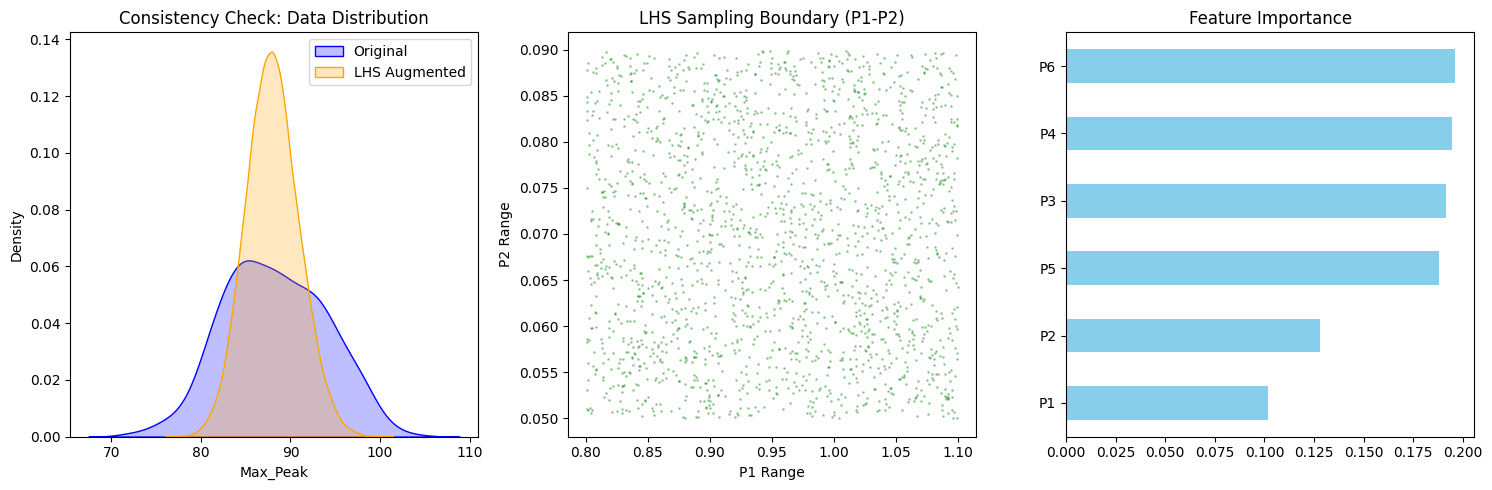

In [7]:
# 5. 시각적 검증 및 일관성 확인 그래프
plt.figure(figsize=(15, 5))

# (1) 분포 일관성 검증 (KDE Plot)
plt.subplot(1, 3, 1)
sns.kdeplot(df_final['Max_Peak'], label='Original', fill=True, color='blue')
sns.kdeplot(df_virtual['Predicted_Peak'], label='LHS Augmented', fill=True, color='orange')
plt.title("Consistency Check: Data Distribution")
plt.legend()

# (2) 범위 준수 확인 (P1 vs P2 공간 채우기)
plt.subplot(1, 3, 2)
plt.scatter(df_virtual['P1'].head(2000), df_virtual['P2'].head(2000), s=1, alpha=0.3, color='green')
plt.title("LHS Sampling Boundary (P1-P2)")
plt.xlabel("P1 Range")
plt.ylabel("P2 Range")

# (3) 모델 피처 중요도
plt.subplot(1, 3, 3)
feat_importances = pd.Series(model.feature_importances_, index=p_cols).sort_values()
feat_importances.plot(kind='barh', color='skyblue')
plt.title("Feature Importance")

plt.tight_layout()
plt.show()

In [8]:
# 6. 요약 정보 요약 정보 출력
print("\n" + "="*50)
print("       [Flip-chip Surrogate Model Summary]       ")
print("="*50)
print(f"1. 통합 원본 데이터 샘플 수 : {len(df_final)} 개")
print(f"2. 증강 가상 데이터 샘플 수 : {len(df_virtual)} 개 (LHS 적용)")
print(f"3. 대리 모델 정확도 (R2)     : {r2_score(y_test, y_pred):.4f}")
print(f"4. 평균 절대 오차 (MAE)      : {mean_absolute_error(y_test, y_pred):.4f}")
print("-"*50)
print("5. 파라미터 탐색 범위 (Boundary Check):")
for col in p_cols:
    v_min, v_max = df_virtual[col].min(), df_virtual[col].max()
    print(f"   - {col}: {v_min:>8.2f} ~ {v_max:>8.2f} (범위 준수 완료)")
print("-"*50)
print(f"6. 가상 데이터 예측 Max Peak 평균: {df_virtual['Predicted_Peak'].mean():.4f}")
print("="*50)


       [Flip-chip Surrogate Model Summary]       
1. 통합 원본 데이터 샘플 수 : 542 개
2. 증강 가상 데이터 샘플 수 : 100000 개 (LHS 적용)
3. 대리 모델 정확도 (R2)     : -0.3413
4. 평균 절대 오차 (MAE)      : 5.1067
--------------------------------------------------
5. 파라미터 탐색 범위 (Boundary Check):
   - P1:     0.80 ~     1.10 (범위 준수 완료)
   - P2:     0.05 ~     0.09 (범위 준수 완료)
   - P3:     0.60 ~     0.72 (범위 준수 완료)
   - P4:     0.10 ~     0.30 (범위 준수 완료)
   - P5:     1.20 ~     1.80 (범위 준수 완료)
   - P6:     0.04 ~     0.08 (범위 준수 완료)
--------------------------------------------------
6. 가상 데이터 예측 Max Peak 평균: 87.9520
